In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/cs-460-muffin-vs-chihuahua-classification-challenge/test_solution_01.csv
/kaggle/input/competitions/cs-460-muffin-vs-chihuahua-classification-challenge/kaggle_test_final/img_4_684.jpg
/kaggle/input/competitions/cs-460-muffin-vs-chihuahua-classification-challenge/kaggle_test_final/img_3_835.jpg
/kaggle/input/competitions/cs-460-muffin-vs-chihuahua-classification-challenge/kaggle_test_final/img_0_340.jpg
/kaggle/input/competitions/cs-460-muffin-vs-chihuahua-classification-challenge/kaggle_test_final/img_2_138.jpg
/kaggle/input/competitions/cs-460-muffin-vs-chihuahua-classification-challenge/kaggle_test_final/img_3_570.jpg
/kaggle/input/competitions/cs-460-muffin-vs-chihuahua-classification-challenge/kaggle_test_final/img_1_210.jpg
/kaggle/input/competitions/cs-460-muffin-vs-chihuahua-classification-challenge/kaggle_test_final/img_2_792.jpg
/kaggle/input/competitions/cs-460-muffin-vs-chihuahua-classification-challenge/kaggle_test_final/img_1_581.jpg
/kaggle/inpu

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

2026-04-19 12:32:09.733125: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776601930.120857      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776601930.224352      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776601931.155672      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776601931.155716      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776601931.155719      55 computation_placer.cc:177] computation placer alr

In [3]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10

In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/competitions/cs-460-muffin-vs-chihuahua-classification-challenge/train",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/competitions/cs-460-muffin-vs-chihuahua-classification-challenge/train",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

Found 4733 files belonging to 2 classes.
Using 3787 files for training.


I0000 00:00:1776601972.079061      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776601972.085517      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 4733 files belonging to 2 classes.
Using 946 files for validation.


In [5]:
class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

In [6]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [7]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
])

In [9]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# 🔹 Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=2),
    tf.keras.callbacks.ModelCheckpoint("best_model.keras", save_best_only=True)
]

# 🔹 Train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,218,788 (16.09 MB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

Epoch 1/10


E0000 00:00:1776602110.834178      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_2_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1776602113.750885     136 cuda_dnn.cc:529] Loaded cuDNN version 91002


119/119 ━━━━━━━━━━━━━━━━━━━━ 32s 147ms/step - accuracy: 0.9582 - loss: 0.1121 - val_accuracy: 0.9979 - val_loss: 0.0186 - learning_rate: 0.0010
Epoch 2/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 12s 96ms/step - accuracy: 0.9939 - loss: 0.0193 - val_accuracy: 0.9989 - val_loss: 0.0064 - learning_rate: 0.0010
Epoch 3/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 11s 90ms/step - accuracy: 0.9953 - loss: 0.0166 - val_accuracy: 0.9968 - val_loss: 0.0076 - learning_rate: 0.0010
Epoch 4/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 12s 97ms/step - accuracy: 0.9953 - loss: 0.0110 - val_accuracy: 0.9989 - val_loss: 0.0058 - learning_rate: 0.0010
Epoch 5/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 12s 98ms/step - accuracy: 0.9976 - loss: 0.0063 - val_accuracy: 0.9968 - val_loss: 0.0053 - learning_rate: 0.0010
Epoch 6/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 12s 97ms/step - accuracy: 0.9999 - loss: 0.0026 - val_accuracy: 0.9979 - val_loss: 0.0042 - learning_rate: 0.0010
Epoch 7/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 11s 93ms/step - accuracy: 0.9976 - loss: 0.005

In [10]:
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print("Final Train Accuracy:", train_acc)
print("Final Validation Accuracy:", val_acc)

Final Train Accuracy: 0.9976234436035156
Final Validation Accuracy: 0.9989429116249084


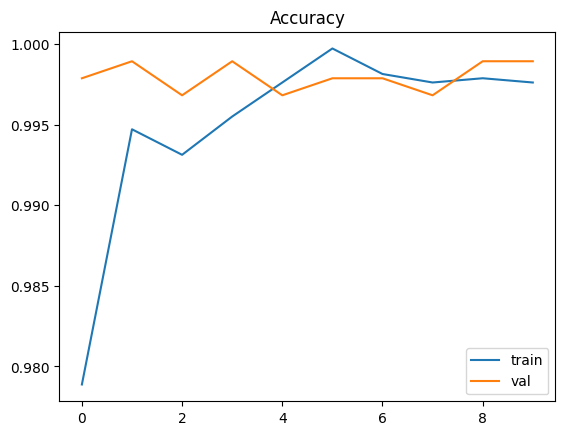

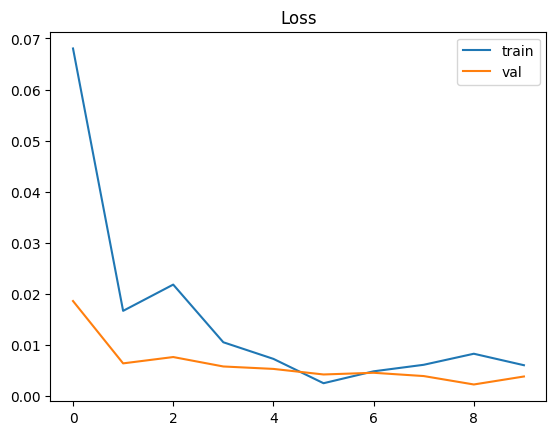

In [11]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['train', 'val'])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['train', 'val'])
plt.show()

In [14]:
df = pd.read_csv('/kaggle/input/competitions/cs-460-muffin-vs-chihuahua-classification-challenge/test_solution_01.csv')
df.head()

,ID,Label
0,img_0_0.jpg,muffin
1,img_0_10.jpg,muffin
2,img_0_1000.jpg,chihuahua
3,img_0_1037.jpg,chihuahua
4,img_0_105.jpg,chihuahua


In [16]:
import pandas as pd
import numpy as np
import os
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input

IMG_SIZE = 224

test_dir = "/kaggle/input/competitions/cs-460-muffin-vs-chihuahua-classification-challenge/kaggle_test_final"

file_names = sorted(os.listdir(test_dir))

pred_labels = []

for img_name in file_names:
    img_path = os.path.join(test_dir, img_name)
    
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img = image.img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)
    
    pred = model.predict(img, verbose=0)[0][0]
    
    # 🔥 FIXED LINE
    label = "muffin" if pred > 0.5 else "chihuahua"
    
    pred_labels.append(label)

submission = pd.DataFrame({
    "ID": file_names,
    "Label": pred_labels
})

submission.to_csv("submission.csv", index=False)

print("✅ Submission file created!")

✅ Submission file created!
